# 심화 실습: 반응 에너지 · 유한온도 Gibbs 에너지 · 다중 물성 스크리닝

**AI for Materials Science — Hands-on session 1 (선택 심화 실습)**

이번 노트북에서는 앞에서 다룬 재료 데이터를 반응과 후보 선별 문제에 적용해 보겠습니다. 순서는 다음과 같습니다.

1. 계산 자료로 반응식을 맞추고, 반응 에너지와 전압을 구합니다.
2. 0 K DFT 형성 엔탈피를 출발점으로 SISSO 고체 자유에너지 모형을 적용해 온도에 따른 반응 구동력을 살펴봅니다.
3. 여러 물성 조건과 결측값을 함께 고려해 열전 재료 후보를 고릅니다.

별도 안내가 없으면 위에서 아래로 실행하면 됩니다. 캐시 자료를 사용하는 기본 실습은 API 키 없이 끝까지 실행되며,
현재 Materials Project(MP) 자료를 조회하는 부분은 선택 사항입니다.

## 진행 순서와 시간

처음에는 반응식의 계수와 에너지 단위를 맞추는 데 집중해주세요. 이 부분을 이해하면 뒤에서 온도를 바꾸어 Gibbs 에너지를 계산할 때도 같은 흐름으로 따라갈 수 있습니다.

캐시를 이용한 반응 계산은 약 15분, Gibbs 에너지는 20분, 물성 스크리닝은 15분 정도 걸립니다. API 키가 있다면 중간의 MP 비교 실습도 해보세요. 약 15분을 더 잡으면 됩니다.

실험값과 계산값을 다루는 셀이 모두 있으니, 각 표가 어떤 데이터를 사용했는지 확인하면서 진행하겠습니다.

## 사용할 데이터 확인

여기서 쓰는 두 캐시 파일은 pymatgen 저장소에 공개된 테스트 자료입니다. 실제 MP 계산 자료를 담고 있지만,
현재 MP 데이터베이스 전체를 내려받은 자료는 아닙니다. 결과 표의 `data_origin`을 함께 확인해 주세요.

- Li–Fe–P–O 캐시에는 보정된 GGA/GGA+U `ComputedEntry` 859개가 있습니다. 구조 정보가 없으므로 각 조성에서
  에너지가 가장 낮은 계산 자료를 고릅니다.
- Mn–O 캐시에는 구조를 포함한 보정 자료 6개가 있습니다. pymatgen의 Gibbs 에너지 단위 테스트에도 쓰이는 자료입니다.
- UCSB 열전 자료는 논문에서 수집한 실험 측정값입니다.
- 선택 셀에서 조회하는 MP 요약 및 열역학 자료는 계산값입니다.

API 키는 환경 변수나 숨김 입력으로 넣어주세요. 현재 MP를 조회한 결과는 함께 받은 캐시와 달라질 수 있습니다.
r2SCAN 자료가 없는 경우에는 상태 표에서 어떤 자료가 빠졌는지 확인하면 됩니다.

## 0. 실행 환경 준비

세 노트북은 같은 `requirements.txt`를 사용합니다. 배포 ZIP 전체를 풀고, 노트북과 이 파일이 함께 있는 폴더에서 실행해주세요. 수업 자료는 Python 3.12에서 확인했습니다.

아래 셀은 필요한 패키지와 버전을 확인하고, 없거나 버전이 다른 경우에만 설치합니다. `pymatgen-core`도 함께 버전을 맞춥니다.

**패키지 설치가 실행되었다면 커널/런타임을 재시작한 뒤 첫 셀부터 다시 실행해주세요.** 버전이 이미 맞으면 바로 다음 셀로 넘어가면 됩니다. Colab에서는 재시작 후 `%cd /content/Hands-on-session1_2026`처럼 압축을 푼 폴더로 다시 이동해주세요.


In [1]:
## 수업에 필요한 패키지가 준비되어 있는지 확인하고, 필요한 경우 설치하겠습니다.
## 주석은 코드를 읽는 사람을 위한 설명입니다. Python은 주석 줄을 실행하지 않습니다.
## import는 다른 곳에서 만든 도구를 불러오는 명령입니다. 여기서는 환경과 설치 상태를 확인합니다.
import os
import sys
import subprocess
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version as package_version

## if는 조건이 맞을 때만 아래의 들여쓰기한 코드를 실행합니다. Python 버전이 낮으면 멈춥니다.
if sys.version_info < (3, 12):
    raise RuntimeError("이 실습은 Python 3.12 이상이 필요합니다. 먼저 커널/런타임을 바꿔주세요.")

## Path는 파일 위치를 다루는 도구입니다. 현재 폴더의 requirements.txt를 찾습니다.
requirements_path = Path("requirements.txt")
if not requirements_path.is_file():
    raise FileNotFoundError(
        "requirements.txt를 찾지 못했습니다. 배포 ZIP 전체를 풀고, "
        "노트북과 requirements.txt가 있는 폴더에서 실행해주세요."
    )

## 딕셔너리 {}에 패키지 이름과 필요한 버전을 짝지어 저장하겠습니다.
required_versions = {}
## for는 파일의 줄을 하나씩 꺼내 같은 처리를 반복합니다.
for line in requirements_path.read_text(encoding="utf-8").splitlines():
    ## 설치 목록의 # 뒤 설명과 양끝 공백을 제외하고 실제 패키지 정보만 읽습니다.
    specification = line.split("#", 1)[0].strip()
    if specification:
        ## ==를 기준으로 나눈 패키지 이름과 버전을 두 변수에 각각 저장합니다.
        distribution, expected = specification.split("==", 1)
        required_versions[distribution] = expected

## 리스트 []에 설치가 필요하거나 버전이 다른 패키지를 모읍니다.
version_mismatches = []
for distribution, expected in required_versions.items():
    ## try로 버전 확인을 시도하고, 패키지가 없으면 except에서 None으로 표시합니다.
    try:
        installed = package_version(distribution)
    except PackageNotFoundError:
        installed = None
    ## !=는 서로 다르다는 비교입니다. append()는 리스트 끝에 항목을 추가합니다.
    if installed != expected:
        version_mismatches.append((distribution, installed, expected))

## 설치 후에는 재시작이 필요하다는 표시를 남겨, 다음 셀에서 확인하게 합니다.
_AI4M_RESTART_REQUIRED = globals().get("_AI4M_RESTART_REQUIRED", False)
## 리스트가 비어 있지 않을 때만 설치를 진행합니다. 버전이 맞으면 이 부분을 건너뜁니다.
if version_mismatches:
    for distribution, installed, expected in version_mismatches:
        print(f"{distribution}: {installed or '미설치'} → {expected}")
    if os.getenv("AI4M_SKIP_INSTALL") == "1":
        raise RuntimeError("설치를 건너뛰도록 설정했지만 패키지 버전이 맞지 않습니다.")
    ## 현재 커널의 Python으로 requirements.txt에 적힌 패키지 버전을 설치합니다.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-r", str(requirements_path)
    ])
    _AI4M_RESTART_REQUIRED = True

## 설치를 했다면 커널/런타임을 재시작하고 첫 셀부터 다시 실행해주세요.
if _AI4M_RESTART_REQUIRED:
    print("설치가 끝났습니다. 커널/런타임을 재시작한 뒤 첫 셀부터 다시 실행해주세요.")
else:
    print(f"Python {sys.version.split()[0]}: 수업용 패키지 {len(required_versions)}개의 버전을 확인했습니다.")

Python 3.12.13: 수업용 패키지 17개의 버전을 확인했습니다.


In [2]:
## 반응 계산·표 정리·그래프에 사용할 도구를 불러오고, 자료와 결과를 저장할 폴더를 준비합니다.
## 앞 셀에서 패키지를 설치했다면, 이전 버전이 메모리에 남지 않도록 재시작 여부를 확인합니다.
if globals().get("_AI4M_RESTART_REQUIRED", False):
    raise RuntimeError("커널/런타임을 재시작한 뒤 첫 셀부터 다시 실행해주세요.")

## import는 다른 패키지의 기능을 불러옵니다. as로 정한 plt, np, pd는 뒤에서 쓸 짧은 이름입니다.
from importlib.metadata import version
from pathlib import Path
import gzip
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from monty.json import MontyDecoder
from pymatgen.analysis.phase_diagram import PhaseDiagram
from pymatgen.analysis.reaction_calculator import ComputedReaction
from pymatgen.analysis.structure_matcher import StructureMatcher
from pymatgen.core import Composition
from pymatgen.entries.computed_entries import (
    ComputedEntry,
    GibbsComputedStructureEntry,
)

## 딕셔너리 내포는 패키지 이름을 하나씩 읽어 {이름: 설치 버전} 형태로 모읍니다.
versions = {name: version(name) for name in
            ["numpy", "pandas", "matplotlib", "pymatgen", "mp-api"]}
versions["python"] = sys.version.split()[0]
print(versions)

## def는 나중에 호출할 함수를 정의합니다. return은 찾은 폴더를 돌려주고 함수 실행을 끝냅니다.
def find_data_dir():
    ## 현재 작업 폴더부터 상위 폴더까지 차례로 탐색합니다. *는 여러 상위 경로를 목록에 펼쳐 넣습니다.
    for root in [Path.cwd(), *Path.cwd().parents]:
        candidate = root / "ai4m_data"
        if (candidate / "sources.json").exists():
            return candidate
    raise FileNotFoundError("ai4m_data/sources.json을 찾지 못했습니다.")

## 함수를 호출해 자료 폴더를 찾고, 결과 폴더가 이미 있어도 오류 없이 사용할 수 있게 만듭니다.
DATA_DIR = find_data_dir()
OUTPUT_DIR = Path.cwd() / "outputs" / "03_advanced"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("data:", DATA_DIR)
print("outputs:", OUTPUT_DIR)

{'numpy': '2.5.3', 'pandas': '2.3.3', 'matplotlib': '3.11.1', 'pymatgen': '2026.5.4', 'mp-api': '0.46.5', 'python': '3.12.13'}
data: /Users/kwongibaek/Desktop/workspace/26_AI4M/26년_1학기/Hands-on-session1_2026/ai4m_data
outputs: /Users/kwongibaek/Desktop/workspace/26_AI4M/26년_1학기/Hands-on-session1_2026/outputs/03_advanced


In [3]:
## 배포 자료의 기록을 읽고, 파일 내용이 기록된 SHA-256 값과 일치하는지 확인합니다.
## JSON 형식의 텍스트를 파이썬 딕셔너리으로 바꿉니다. 파일 이름으로 각 자료의 출처 기록을 찾을 수 있습니다.
manifest = json.loads((DATA_DIR / "sources.json").read_text(encoding="utf-8"))

## 파일 이름을 받는 검증 함수입니다. 같은 절차를 여러 파일에 재사용합니다.
def verify_cached_file(filename):
    record = manifest[filename]
    expected = record.get("sha256")
    ## 파일 내용으로 계산한 해시값을 기록된 값과 비교합니다. 기록값이 있는데 다르면 오류로 중단합니다.
    actual = hashlib.sha256((DATA_DIR / filename).read_bytes()).hexdigest()
    if expected and actual != expected:
        raise ValueError(f"{filename}: SHA-256 불일치")
    ## 딕셔너리은 항목 이름과 값을 짝지어 저장합니다. get은 해당 항목이 없어도 조회할 수 있게 합니다.
    return {"file": filename, "verified": bool(expected),
            "downloaded": record.get("downloaded"),
            "description": record.get("description")}

## 파일별 검사 결과를 목록으로 모은 뒤 DataFrame으로 바꾸어 표로 표시합니다.
provenance = pd.DataFrame([
    verify_cached_file("Li-Fe-P-O_entries.json"),
    verify_cached_file("Mn-O_entries.json"),
    verify_cached_file("ucsb_thermoelectrics.json.gz"),
])
display(provenance)

,file,verified,downloaded,description
0,Li-Fe-P-O_entries.json,True,2026-09-08,Historical MP-derived computed-entry fixture f...
1,Mn-O_entries.json,True,2026-09-08,Historical MP-derived computed-structure-entry...
2,ucsb_thermoelectrics.json.gz,True,2026-09-08,Original compressed matminer snapshot of the e...


## 1. LiFePO₄ 탈리 반응: 계산 셀에서 화학식 단위로

먼저 다음 탈리 반응의 에너지를 구해 보겠습니다.

$$\mathrm{LiFePO_4 \rightarrow FePO_4 + Li}$$

캐시의 계산 셀 크기는 서로 다릅니다. `energy_per_atom`을 그대로 빼면 LiFePO₄의 7 atoms/f.u. 기준과
FePO₄의 6 atoms/f.u. 기준을 섞게 됩니다. 따라서 `ComputedReaction`으로 조성을 환원하고, 모든 에너지를 같은
화학식 단위로 맞춘 뒤 비교하겠습니다. 이어지는 표에서는 목표 조성별 계산 자료 수부터 확인합니다.

In [4]:
## 저장된 Li–Fe–P–O 계산 자료를 pymatgen 객체로 복원하고, 자료 수와 계산 방법을 살펴봅니다.
raw_lfp = json.loads((DATA_DIR / "Li-Fe-P-O_entries.json").read_text())
## 목록 내포는 raw_lfp의 항목을 하나씩 변환합니다. 복원한 객체에서 조성·에너지·계산 조건을 읽습니다.
lfpo_entries = [MontyDecoder().process_decoded(item) for item in raw_lfp]

## len은 항목 수를 셉니다. 집합은 중복 객체 종류를 제거하고, value_counts는 계산 방법별 개수를 셉니다.
print("계산 자료 수:", len(lfpo_entries))
print("객체 종류:", sorted({type(e).__name__ for e in lfpo_entries}))
print("계산 방법:", pd.Series([e.parameters.get("run_type") for e in lfpo_entries]).value_counts().to_dict())

계산 자료 수: 859
객체 종류: ['ComputedEntry']
계산 방법: {'GGA+U': 747, 'GGA': 112}


In [5]:
## 반응에 필요한 각 화학식의 계산 자료가 몇 개씩 있는지 확인합니다.
target_counts = []
## for는 화학식을 하나씩 꺼내 반복합니다. reduced_formula는 원자 수의 공통 배수를 줄인 화학식입니다.
for formula in ["LiFePO4", "FePO4", "Li", "Fe", "P", "O2"]:
    ## 비교 결과 True는 합산할 때 1로 계산됩니다. append는 화학식과 개수를 결과 목록에 한 행씩 추가합니다.
    count = sum(e.composition.reduced_formula == formula for e in lfpo_entries)
    target_counts.append({"reduced_formula": formula, "count": count})
display(pd.DataFrame(target_counts))

,reduced_formula,count
0,LiFePO4,64
1,FePO4,26
2,Li,9
3,Fe,6
4,P,13
5,O2,20


### 각 조성에서 기준 계산 자료 고르기

같은 조성에도 구조가 다른 계산 결과가 여러 개 있을 수 있습니다. `PhaseDiagram.get_e_above_hull`을 사용해 각 조성에서
convex hull에 가장 가까운 계산 자료를 선택하겠습니다. 다음 표에는 반응물, 생성물, Li 기준상의 ID와 셀 크기,
`energy_above_hull`이 정리됩니다.

이 캐시에는 구조가 들어 있지 않으므로 여기서 얻는 값은 조성별 평형 종단점을 사용한 반응 에너지입니다.
실제 충·방전 과정에서 골격을 유지하는 topotactic 경로가 확인되었다는 뜻은 아닙니다.

In [6]:
## 상평형도를 구성하고, LiFePO4·FePO4·Li 반응에 사용할 계산 자료를 고릅니다.
lfpo_pd = PhaseDiagram(lfpo_entries)

## 같은 화학식의 후보 중 상평형도 기준 불안정 에너지가 가장 작은 자료를 반환하는 함수입니다.
def lowest_hull_entry(entries, phase_diagram, reduced_formula):
    ## 목록 내포의 if로 화학식이 일치하는 항목만 남깁니다. 후보 목록이 비어 있으면 오류를 냅니다.
    candidates = [e for e in entries if e.composition.reduced_formula == reduced_formula]
    if not candidates:
        raise LookupError(f"{reduced_formula} 계산 자료가 없습니다.")
    ## min의 key는 비교 기준입니다. 여기서는 원자당 energy above hull 값을 비교합니다.
    return min(candidates, key=phase_diagram.get_e_above_hull)

lfp_entry = lowest_hull_entry(lfpo_entries, lfpo_pd, "LiFePO4")
fp_entry = lowest_hull_entry(lfpo_entries, lfpo_pd, "FePO4")
## Li 기준은 순수 Li 계산 자료에서 고릅니다. lambda는 각 자료의 원자당 에너지를 반환하는 짧은 함수입니다.
li_entry = min(
    (e for e in lfpo_entries if e.composition.is_element
     and e.composition.elements[0].symbol == "Li"),
    key=lambda e: e.energy_per_atom,
)
## 선택 결과를 반응물, 생성물, Li 기준의 순서로 묶어 이후 셀에서 재사용합니다.
selected_lfp_entries = [lfp_entry, fp_entry, li_entry]

In [7]:
## 선택한 세 계산 자료의 조성, 계산 방법, 에너지 기준을 한 표에서 확인합니다.
## zip은 역할 이름과 계산 자료를 순서대로 짝짓습니다. 각 딕셔너리은 표의 한 행이 됩니다.
selected_table = pd.DataFrame([
    {
        "role": role,
        "calculation_id": e.entry_id,
        "cell_formula": e.composition.formula,
        "reduced_formula": e.composition.reduced_formula,
        "atoms_in_cell": e.composition.num_atoms,
        "run_type": e.parameters.get("run_type"),
        ## 보정 에너지는 계산 셀 전체의 eV이고, hull 위 에너지는 eV/atom입니다. 단위와 기준 크기를
        ## 구분합니다.
        "corrected_energy_eV_cell": e.energy,
        "e_above_hull_eV_atom": lfpo_pd.get_e_above_hull(e),
    }
    for role, e in zip(["reactant", "product", "Li reference"], selected_lfp_entries)
])
display(selected_table)

,role,calculation_id,cell_formula,reduced_formula,atoms_in_cell,run_type,corrected_energy_eV_cell,e_above_hull_eV_atom
0,reactant,mp-19017,Li4 Fe4 P4 O16,LiFePO4,28.0,GGA+U,-213.504632,0.0
1,product,mp-540111,Fe4 P4 O16,FePO4,24.0,GGA+U,-192.696217,0.0
2,Li reference,mp-135,Li1,Li,1.0,GGA,-1.907973,0.0


### 반응 에너지와 전압 읽기

탈리 반응에서 LiFePO₄의 계수가 1이 되도록 정규화하겠습니다. 계산 결과의 단위 `eV / reaction`은 이 경우
LiFePO₄ 한 화학식 단위당 eV를 뜻합니다. 출력 표에는 같은 값을 kJ/mol-reaction으로 바꾼 결과도 함께 나옵니다.

전압 식은 에너지 단위에 따라 분모를 분명히 써야 합니다. 몰 반응 Gibbs 에너지를 J/mol로 쓸 때 탈리 방향의 전압은

$$V_{\rm delithiation}=\frac{\Delta G_{\rm delithiation,molar}}{nF}$$

입니다. $F$는 Faraday 상수이고 $n$은 반응당 이동 전자 수입니다. 에너지를 eV/reaction으로 쓰면 같은 식은 수치상
$V_{\rm delithiation}=\Delta G_{\rm delithiation}/n$이 됩니다. 여기서는 Li 1개와 전자 1개가 이동하므로 $n=1$입니다.
반대 방향인 삽입 반응에서는 $V=-\Delta G_{\rm insertion,molar}/(nF)$로 같은 양의 전압을 얻습니다.
아래 값은 유한온도 Gibbs 에너지가 아니라 보정된 0 K DFT 반응 에너지로 구한 전압 근사값입니다.

In [8]:
## 반응식을 LiFePO4 한 화학식 단위 기준으로 맞추고, 반응 에너지와 전압 추정치를 계산합니다.
## 반응 1회당 eV를 같은 반응의 kJ/mol로 환산하는 상수와, 전자 1 mol의 전하량을 준비합니다.
EV_PER_PARTICLE_TO_KJ_PER_MOL = 96.48533212
FARADAY_C_PER_MOL = 96485.33212
ELECTRONS_PER_REACTION = 1

## ComputedReaction이 원자 수에 맞게 반응 계수를 구합니다. normalize_to는 지정한 화학식의 계수 크기를 1로
## 맞춥니다.
def normalized_reaction(reactants, products, normalize_formula):
    reaction = ComputedReaction(reactants, products)
    reaction.normalize_to(Composition(normalize_formula).reduced_composition)
    return reaction

## 원소별로 반응 계수 × 원자 수를 합산하는 함수입니다. 반응물 계수는 음수, 생성물 계수는 양수입니다.
def balance_residual(reaction):
    residual = {}
    for coeff, comp in zip(reaction.coeffs, reaction.all_comp):
        for element, amount in comp.get_el_amt_dict().items():
            ## get(element, 0.0)은 처음 만난 원소의 합을 0에서 시작하게 합니다. 균형이 맞으면 모든 원소의
            ## 합이 0에 가깝습니다.
            residual[element] = residual.get(element, 0.0) + coeff * amount
    return residual

## 대괄호는 반응물·생성물 목록입니다. 정규화한 반응식의 에너지를 읽고 mol 기준 단위로 변환합니다.
lfp_reaction = normalized_reaction([lfp_entry], [fp_entry, li_entry], "LiFePO4")
dE_lfp_eV = lfp_reaction.calculated_reaction_energy
dE_lfp_kJ_per_mol = dE_lfp_eV * EV_PER_PARTICLE_TO_KJ_PER_MOL
## 이 코드의 탈리튬 반응 방향에서 에너지를 전하량으로 나눠 전압을 추정합니다. 1000은 kJ를 J로 바꿉니다.
lfp_voltage_V = (
    dE_lfp_kJ_per_mol * 1000
    / (ELECTRONS_PER_REACTION * FARADAY_C_PER_MOL)
)
## assert는 조건이 거짓이면 중단합니다. 부동소수점 오차를 고려해 두 전압 계산식이 같은지 확인합니다.
assert np.isclose(lfp_voltage_V, dE_lfp_eV / ELECTRONS_PER_REACTION)

In [9]:
## 계산한 반응식과 반응 에너지·전압을 출처와 함께 한 행의 결과 표로 정리합니다.
## 딕셔너리의 키가 열 이름이 됩니다. eV/반응과 kJ/mol 반응은 앞 셀에서 정한 동일한 반응식 기준입니다.
lfp_result = pd.DataFrame([{
    "data_origin": "historical MP GGA/GGA+U fixture (computed)",
    "reaction": str(lfp_reaction),
    "delta_E_eV_per_reaction": dE_lfp_eV,
    "delta_E_kJ_per_mol_reaction": dE_lfp_kJ_per_mol,
    "electrons_per_reaction": ELECTRONS_PER_REACTION,
    "voltage_estimate_V": lfp_voltage_V,
}])
display(lfp_result)

,data_origin,reaction,delta_E_eV_per_reaction,delta_E_kJ_per_mol_reaction,electrons_per_reaction,voltage_estimate_V
0,historical MP GGA/GGA+U fixture (computed),LiFePO4 -> FePO4 + Li,3.294131,317.835335,1,3.294131


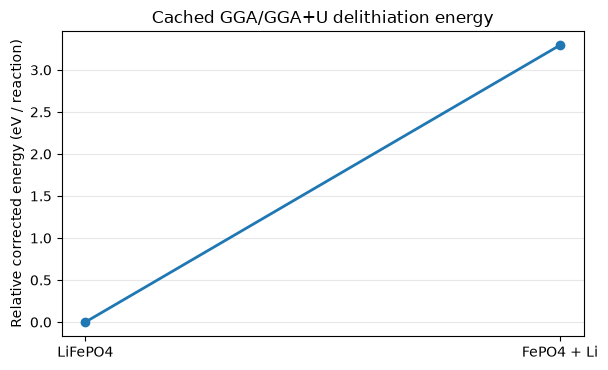

In [10]:
## LiFePO4의 에너지를 0으로 두고 생성물의 상대 에너지를 그려 반응 에너지 차이를 표시합니다.
## fig는 그림 전체, ax는 좌표축입니다. plot에 x좌표와 y좌표 목록을 같은 순서로 전달합니다.
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot([0, 1], [0, dE_lfp_eV], marker="o", linewidth=2)
ax.set_xticks([0, 1], ["LiFePO4", "FePO4 + Li"])
ax.set_ylabel("Relative corrected energy (eV / reaction)")
ax.set_title("Cached GGA/GGA+U delithiation energy")
ax.grid(axis="y", alpha=0.3)
## 축 제목이 겹치지 않게 여백을 조정한 뒤 PNG로 저장하고, 노트북에도 그림을 표시합니다.
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "lfp_cached_delithiation_energy.png", dpi=180)
plt.show()

### 계산 기준 확인

반응 에너지를 해석하기 전에 세 가지를 확인하겠습니다. 원소 수가 양변에서 맞는지, LiFePO₄의 계수가 1인지,
그리고 계산 셀을 화학식 단위로 줄여도 결과가 달라지지 않는지 검사합니다. 마지막 검사는 크기가 다른 supercell의
총에너지를 그대로 비교하는 실수를 찾는 데 도움이 됩니다. 셀 끝에 `PASS`가 나오면 세 검사를 통과한 것입니다.

In [11]:
## 원소별 반응 균형과 계수 기준을 검사하고, 계산 셀 크기를 바꿔도 반응 에너지가 같은지 확인합니다.
residual = balance_residual(lfp_reaction)
## 원소별 잔차의 절댓값이 모두 허용 오차보다 작아야 합니다. LiFePO4의 계수 크기도 1인지 검사합니다.
assert max(abs(value) for value in residual.values()) < 1e-10
assert np.isclose(abs(lfp_reaction.get_coeff(Composition("LiFePO4"))), 1.0)

## formula_unit 정규화는 각 자료의 조성과 에너지를 화학식 단위 기준으로 함께 나눕니다.
normalized_entries = [entry.normalize("formula_unit") for entry in selected_lfp_entries]
## [0]은 첫 번째 자료이고 [1:]은 두 번째부터 끝까지입니다. 같은 반응을 다시 구성해 에너지를 비교합니다.
normalized_again = normalized_reaction(
    [normalized_entries[0]], normalized_entries[1:], "LiFePO4"
)
assert np.isclose(
    normalized_again.calculated_reaction_energy,
    dE_lfp_eV,
    atol=1e-10,
)
print("balance:", residual)
print("normalization invariant: PASS")

balance: {'Li': np.float64(-4.440892098500626e-16), 'Fe': np.float64(2.220446049250313e-16), 'P': np.float64(2.220446049250313e-16), 'O': np.float64(8.881784197001252e-16)}
normalization invariant: PASS


**짧은 과제 1:** `lfp_entry.energy_per_atom - fp_entry.energy_per_atom`을 전압으로 해석할 수 없는 이유를
반응식과 단위 기준을 사용해 설명해 보세요.

*풀이 방향은 수업 후 자료에서 확인할 수 있습니다.*

## 2. SISSO로 온도에 따른 Gibbs 형성 에너지 추정하기

이제 온도 효과를 포함해 보겠습니다. [Bartel 등의 원 논문](https://doi.org/10.1038/s41467-018-06682-4)에서는
0 K DFT 형성 에너지를 형성 엔탈피의 근사값으로 사용하고, 다음 SISSO 고체 자유에너지 항을 더합니다.

$$G^\delta(T)=\left[-2.48\!\times\!10^{-4}\ln V
-8.94\!\times\!10^{-5}\frac{m}{V}\right]T+0.181\ln T-0.882$$

$V$는 원자당 부피(Å³/atom), $m$은 reduced mass(amu)입니다. pymatgen 구현이 계산하는 형성 Gibbs 에너지는
다음처럼 정리할 수 있습니다.

$$G_f(T)\approx N\left[\Delta H_{f,\mathrm{DFT}}(0\,\mathrm K)+G^\delta(T)\right]
-\sum_i n_iG_i^{\mathrm{element}}(T)$$

여기서 API의 `formation_energy_per_atom` 또는 0 K phase diagram의 형성 에너지를
$\Delta H_{f,\mathrm{DFT}}(0\,\mathrm K)$의 근사 입력으로 씁니다. 이 값을 실험 형성 엔탈피로 바꾸어 해석하는 것이 아니라,
보정된 DFT 기준값에 SISSO 온도 항과 표준상태 원소 기준을 적용하는 절차입니다. 따라서 라이브 경로에서도
`formation_energy_per_atom`을 반드시 조회합니다. `GibbsComputedStructureEntry.energy`는 계산 자료 전체 조성의
형성 Gibbs 에너지(eV)를 반환하므로, 원자당 값은 `energy_per_atom`으로 확인해야 합니다.

이 모형의 외부 시험 오차는 약 46 meV/atom이었고, 논문에서 검증한 온도 범위는 300–1800 K입니다. 여기서는 다음 산소
방출 반응을 계산합니다.

$$\mathrm{2\,MnO_2 \rightarrow Mn_2O_3 + \tfrac12 O_2}$$

원소 표준상태의 형성 Gibbs 에너지는 0으로 둡니다. 또한 이 계산은 표준 압력을 기준으로 하며
$RT\ln(p_{O_2}/p^\circ)$ 항은 포함하지 않습니다. 첫 번째 그래프는 MnO₂와 Mn₂O₃의 형성 $G(T)$를,
두 번째 그래프는 표준 압력에서의 반응 $\Delta G(T)$를 보여 줍니다. 다른 산소 분압의 평형선으로 읽으면 안 됩니다.

In [12]:
## Mn–O 계산 자료를 복원하고, 각 조성의 원자당 에너지와 상평형도 기준 안정성을 표로 정리합니다.
raw_mno = json.loads((DATA_DIR / "Mn-O_entries.json").read_text())
## 저장된 항목을 pymatgen 객체로 바꾸고, 같은 자료들로 상평형도를 구성합니다.
mno_entries = [MontyDecoder().process_decoded(item) for item in raw_mno]
mno_pd = PhaseDiagram(mno_entries)

## 계산 자료 하나마다 딕셔너리 한 개를 만듭니다. energy와 hull 위 에너지는 모두 eV/atom 기준으로 비교합니다.
mno_summary = pd.DataFrame([
    {
        "calculation_id": e.entry_id,
        "formula": e.composition.reduced_formula,
        "run_type": e.parameters.get("run_type"),
        "energy_eV_atom": e.energy_per_atom,
        "e_above_hull_eV_atom": mno_pd.get_e_above_hull(e),
    }
    for e in mno_entries
]).sort_values("formula")
## sort_values로 화학식 순서에 맞춰 정리한 표를 표시합니다.
display(mno_summary)

,calculation_id,formula,run_type,energy_eV_atom,e_above_hull_eV_atom
3,mp-35,Mn,GGA,-9.161706,0.0
5,mp-1172875,Mn2O3,GGA+U,-8.661783,0.0
2,mp-18759,Mn3O4,GGA+U,-8.818638,0.0
0,mp-19006,MnO,GGA+U,-9.048277,0.0
1,mp-19395,MnO2,GGA+U,-8.172952,0.0
4,mp-12957,O2,GGA,-4.947955,0.0


In [13]:
## 300–1800 K에서 Mn 산화물의 Gibbs 에너지와 분해 반응의 Gibbs 에너지를 온도별로 계산합니다.
## 화학식이 같은 자료만 남긴 뒤 원자당 에너지가 가장 낮은 자료를 고르는 재사용 함수입니다.
def lowest_formula_entry(entries, formula):
    candidates = [e for e in entries if e.composition.reduced_formula == formula]
    if not candidates:
        raise LookupError(formula)
    return min(candidates, key=lambda e: e.energy_per_atom)

## 온도 temp_K를 전달하면 기존 구조 자료에서 그 온도의 Gibbs 에너지 모형 자료를 만듭니다.
def mno_entries_at_temperature(temp_K):
    return GibbsComputedStructureEntry.from_entries(mno_entries, temp=temp_K)

## 주어진 온도에서 세 상을 고르고 반응을 만드는 함수입니다. 뒤의 검증 셀에서도 호출합니다.
def mno_reaction_at_temperature(temp_K):
    gibbs_entries = mno_entries_at_temperature(temp_K)
    mn_o2 = lowest_formula_entry(gibbs_entries, "MnO2")
    mn2_o3 = lowest_formula_entry(gibbs_entries, "Mn2O3")
    oxygen = lowest_formula_entry(gibbs_entries, "O2")
    reaction = ComputedReaction([mn_o2], [mn2_o3, oxygen])
    ## factor=2는 MnO2의 계수 크기를 2로 맞춥니다. 이후 반응 에너지는 이 반응식 1회 기준입니다.
    reaction.normalize_to(Composition("MnO2"), factor=2)
    return reaction

## arange는 끝값을 포함하지 않으므로 1801을 써서 300, 400, …, 1800 K 목록을 만듭니다.
temperature_grid = np.arange(300, 1801, 100)
gibbs_rows = []
formation_rows = []
## 온도를 하나씩 바꾸며 계산을 반복합니다. 온도별로 각 상의 최저 에너지 자료를 다시 선택합니다.
for temp in temperature_grid:
    temp_entries = mno_entries_at_temperature(int(temp))
    mn_o2 = lowest_formula_entry(temp_entries, "MnO2")
    mn2_o3 = lowest_formula_entry(temp_entries, "Mn2O3")
    oxygen = lowest_formula_entry(temp_entries, "O2")
    reaction = ComputedReaction([mn_o2], [mn2_o3, oxygen])
    reaction.normalize_to(Composition("MnO2"), factor=2)
    ## append로 현재 온도의 반응 결과를 한 행씩 쌓습니다. eV/반응을 kJ/mol 반응으로 함께 환산합니다.
    gibbs_rows.append({
        "temperature_K": temp,
        "reaction": str(reaction),
        "delta_G_eV_per_reaction": reaction.calculated_reaction_energy,
        "delta_G_kJ_per_mol_reaction": (
            reaction.calculated_reaction_energy * EV_PER_PARTICLE_TO_KJ_PER_MOL
        ),
    })
    ## 온도 반복 안에서 두 산화물을 다시 순회하여, 각 상의 형성 Gibbs 에너지를 eV/atom 단위로 따로 모읍니다.
    for phase in [mn_o2, mn2_o3]:
        formation_rows.append({
            "temperature_K": temp,
            "formula": phase.composition.reduced_formula,
            "formation_G_eV_atom": phase.energy_per_atom,
        })
## 목록을 두 표로 변환합니다. iloc[::3]은 위치 기준으로 세 행마다 하나씩 골라 화면에 보여줍니다.
mno_gibbs = pd.DataFrame(gibbs_rows)
mno_formation_gibbs = pd.DataFrame(formation_rows)
display(mno_gibbs.iloc[::3].reset_index(drop=True))

,temperature_K,reaction,delta_G_eV_per_reaction,delta_G_kJ_per_mol_reaction
0,300,2 MnO2 -> Mn2O3 + 0.5 O2,0.541626,52.259005
1,600,2 MnO2 -> Mn2O3 + 0.5 O2,0.309001,29.814035
2,900,2 MnO2 -> Mn2O3 + 0.5 O2,0.102598,9.899191
3,1200,2 MnO2 -> Mn2O3 + 0.5 O2,-0.100542,-9.700864
4,1500,2 MnO2 -> Mn2O3 + 0.5 O2,-0.305985,-29.523033
5,1800,2 MnO2 -> Mn2O3 + 0.5 O2,-0.515462,-49.734547


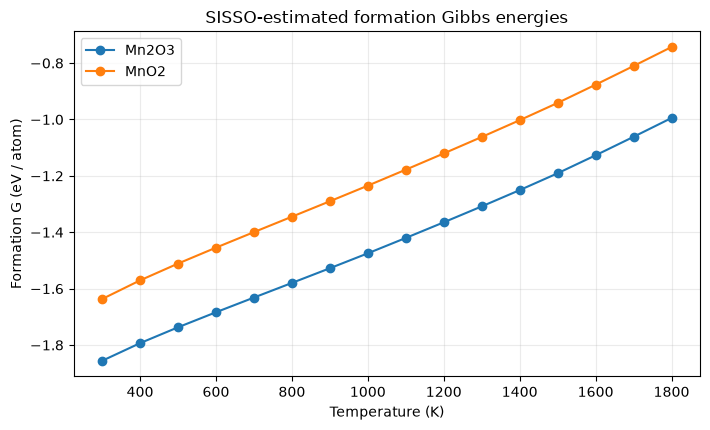

In [14]:
## 각 Mn 산화물의 형성 Gibbs 에너지가 온도에 따라 어떻게 달라지는지 그립니다.
fig, ax = plt.subplots(figsize=(7.2, 4.4))
## groupby는 같은 화학식의 행을 묶습니다. 각 묶음의 온도와 eV/atom 값을 한 곡선으로 연결합니다.
for formula, group in mno_formation_gibbs.groupby("formula"):
    ax.plot(group["temperature_K"], group["formation_G_eV_atom"],
            marker="o", label=formula)
ax.set(xlabel="Temperature (K)", ylabel="Formation G (eV / atom)",
       title="SISSO-estimated formation Gibbs energies")
ax.grid(alpha=0.25)
ax.legend()
## 범례로 두 상을 구분하고, 여백을 정리한 그림을 결과 폴더에 저장합니다.
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mn_o_formation_gibbs_vs_temperature.png", dpi=180)
plt.show()

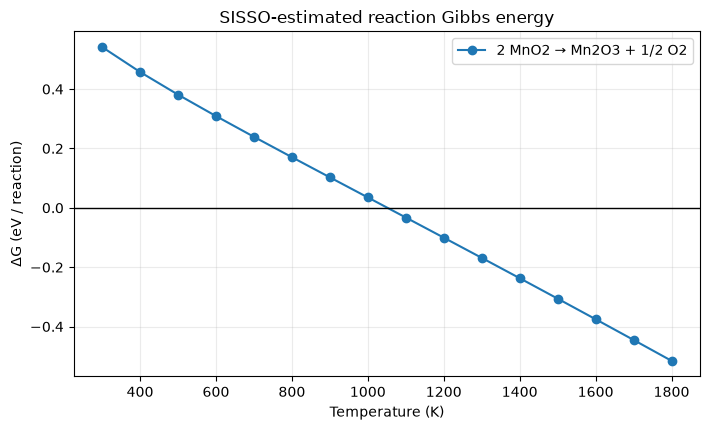

In [15]:
## MnO2 분해 반응의 Gibbs 에너지를 온도별로 그리고 ΔG=0 기준선을 표시합니다.
fig, ax = plt.subplots(figsize=(7.2, 4.4))
## 표에서 온도 열과 반응 Gibbs 에너지 열을 꺼냅니다. 세로축은 앞서 계수를 맞춘 반응 1회당 eV입니다.
ax.plot(
    mno_gibbs["temperature_K"],
    mno_gibbs["delta_G_eV_per_reaction"],
    marker="o",
    label="2 MnO2 → Mn2O3 + 1/2 O2",
)
## 0의 수평선은 반응 Gibbs 에너지의 부호가 바뀌는 구간을 찾는 기준이며, 완성한 그림은 파일로 저장합니다.
ax.axhline(0, color="black", linewidth=1)
ax.set(xlabel="Temperature (K)", ylabel="ΔG (eV / reaction)",
       title="SISSO-estimated reaction Gibbs energy")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "mn_o_gibbs_vs_temperature.png", dpi=180)
plt.show()

In [16]:
## 인접 온도 사이에서 ΔG의 부호가 처음 바뀌는 구간을 찾아 선형 보간으로 0이 되는 온도를 추정합니다.
def first_linear_zero_crossing(x, y):
    ## 입력을 실수 배열로 바꿉니다. 배열을 사용하면 여러 값의 부호를 한 번에 비교할 수 있습니다.
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ## y[:-1]과 y[1:]은 서로 이웃한 값의 배열입니다. signbit로 부호를 비교하고 where로 달라지는 위치를
    ## 찾습니다.
    crossings = np.where(np.signbit(y[:-1]) != np.signbit(y[1:]))[0]
    ## 부호가 바뀌는 구간이 없으면 np.nan을 반환합니다. 이는 이 방법으로 교차 온도를 구하지 못했다는
    ## 표시입니다.
    if crossings.size == 0:
        return np.nan
    ## 첫 번째 교차 구간의 두 점을 직선으로 이었다고 가정하고, 그 직선의 y값이 0인 x좌표를 계산합니다.
    i = crossings[0]
    return x[i] - y[i] * (x[i + 1] - x[i]) / (y[i + 1] - y[i])

## 온도와 ΔG 열을 함수에 전달합니다. 출력의 :.1f는 온도를 소수 첫째 자리까지 표시하는 형식입니다.
crossing_K = first_linear_zero_crossing(
    mno_gibbs["temperature_K"], mno_gibbs["delta_G_eV_per_reaction"]
)
print(f"100 K 격자 사이 선형 보간 ΔG=0 온도: {crossing_K:.1f} K")
print("이는 모형의 평형 추정이며 실제 반응 속도나 산소 분압을 포함하지 않습니다.")

100 K 격자 사이 선형 보간 ΔG=0 온도: 1051.6 K
이는 모형의 평형 추정이며 실제 반응 속도나 산소 분압을 포함하지 않습니다.


### 온도 범위와 기준값 확인

현재 pymatgen 구현은 300–2000 K를 입력으로 받고, 100 K 간격 사이의 값은 보간합니다. 다만 원 논문의 검증 범위는
300–1800 K이므로 이 실습의 그래프도 그 구간에서만 계산합니다. 아래 검사는 고정된 공개 캐시의 300 K와 1800 K 결과,
반응식의 원소 균형, 생성자의 입력 범위를 함께 확인합니다. 모두 맞으면 `PASS`가 출력됩니다.

In [17]:
## 기준 에너지·원자 수 균형·Gibbs 객체의 온도 입력 제한을 검사해 계산 설정이 유지되는지 확인합니다.
## iloc[0]과 iloc[-1]은 첫 행과 마지막 행입니다. 계산값을 기준값과 비교하고 900 K 반응의 균형도 확인합니다.
assert np.isclose(mno_gibbs.iloc[0]["delta_G_eV_per_reaction"], 0.5416264191442313)
assert np.isclose(mno_gibbs.iloc[-1]["delta_G_eV_per_reaction"], -0.5154622541003571)
assert all(abs(v) < 1e-10 for v in balance_residual(mno_reaction_at_temperature(900)).values())

## next는 조건을 만족하는 첫 구조를 꺼냅니다. 여기서는 원소 단체가 아닌 산화물 구조를 검사에 사용합니다.
probe_structure = next(e.structure for e in mno_entries if not e.composition.is_element)
## 의도적으로 허용 범위 밖의 온도를 넣습니다. try/except는 예상한 ValueError가 발생하는지 확인합니다.
for invalid_T in [299, 2001]:
    try:
        GibbsComputedStructureEntry(probe_structure, -1.0, temp=invalid_T)
    except ValueError:
        pass
    ## try가 오류 없이 끝나면 else가 실행됩니다. 잘못된 온도가 받아들여진 경우에는 검사 실패로 처리합니다.
    else:
        raise AssertionError(f"{invalid_T} K가 거부되지 않았습니다.")
print("pinned values, balance, constructor bounds: PASS")

pinned values, balance, constructor bounds: PASS


### 결과를 해석할 때 주의할 점

그래프에서 $\Delta G=0$이 되는 온도는 이 모형 안에서 구한 값이며, 실험 평형 온도를 그대로 뜻하지는 않습니다.
다음 제한을 함께 고려해 주세요.

- SISSO 모형은 화학양론적인 무기 결정 고체를 대상으로 만들었습니다. 결함과 비화학양론 조성에는 검증되지 않았습니다.
- 0 K에서 최적화한 부피를 모든 온도에 사용하므로 열팽창과 phonon 자유에너지를 직접 계산하지 않습니다.
- 용융, 다형체 전이, 온도에 따른 자기 전이는 이 모형으로 예측할 수 없습니다.
- 시험 세트의 오차는 1000 K에서 53 meV/atom, 1800 K에서 92 meV/atom으로 고온에서 커졌습니다.
- DFT 형성 엔탈피의 오차와 SISSO 모형의 오차가 모두 결과에 들어갑니다.
- Mn–O 반응에는 산소 분압 보정과 반응 속도론이 포함되어 있지 않습니다.
- LiFePO₄와 FePO₄에는 0 K 고체 구조를 고정해 사용합니다. Li의 형성 Gibbs 에너지는 원소 표준상태 관례에 따라 0이지만,
  Li 융점 위의 전극 상과 전해질을 별도로 다루지 않았습니다. 따라서 고온 곡선을 검증된 고체-Li 전지 전압으로 해석하지 않습니다.

**짧은 과제 2:** `temperature_grid`를 50 K 간격으로 바꾼 뒤, 선형 보간으로 얻은 $\Delta G=0$ 온도가
얼마나 달라지는지 확인해 보세요. 격자 간격의 영향과 모형 자체의 불확도를 구분해 적어 주세요.

*풀이 방향은 수업 후 자료에서 확인할 수 있습니다.*

## 3. MP 열역학 자료를 계산 방법별로 나누어 비교하기

라이브 조회를 실행할 때는 `thermo_type`을 먼저 확인해야 합니다. 이름이 비슷해도 아래 세 자료는 같은 의미가 아닙니다.

| 요청 | 포함된 계산과 보정 | 표에 표시할 이름 |
|---|---|---|
| `GGA_GGA+U` | PBE와 전이금속의 PBE+U 결과를 MP2020 방식으로 호환 | corrected GGA/GGA+U |
| `R2SCAN` | r2SCAN 계산만 사용 | pure r2SCAN |
| `GGA_GGA+U_R2SCAN` | GGA, GGA+U, r2SCAN을 구조 대응과 에너지 보정으로 연결한 혼합 convex hull | MP mixed |

계산 방법에 따른 차이를 보려면 앞의 두 자료를 각각 요청해야 합니다. MP 버전에 따라 같은 LiFePO₄, FePO₄, Li 종단점의
r2SCAN 계산 자료가 모두 준비되어 있지 않을 수 있습니다. 이 경우 에너지를 0으로 채우지 않고 상태 표에 `자료 없음`과
빠진 조건을 표시합니다. 기본 실행에서는 라이브 조회를 끄므로 같은 표에 `라이브 조회 꺼짐`이 표시됩니다.

In [18]:
## Materials Project 라이브 조회 여부를 정하고, 실행할 때 사용할 API 키를 준비합니다.
## RUN_LIVE_MP는 조회 실행 스위치입니다. 기본값 False에서는 배포된 캐시 자료를 사용합니다.
RUN_LIVE_MP = False
PROMPT_FOR_KEY = False
## os.getenv는 환경 변수 값을 읽습니다. 키가 없으면 빈 문자열을 쓰고, strip은 앞뒤 공백을 제거합니다.
MP_API_KEY = os.getenv("MP_API_KEY", "").strip()
## and로 연결한 조건이 모두 참일 때만 키를 직접 입력받습니다. getpass는 입력 내용을 화면에 표시하지
## 않습니다.
if RUN_LIVE_MP and PROMPT_FOR_KEY and not MP_API_KEY:
    from getpass import getpass
    MP_API_KEY = getpass("Materials Project API key (표시되지 않음): ").strip()

## if/elif/else는 설정과 키 유무에 따라 한 갈래만 실행하여 현재 조회 상태를 알려줍니다.
if RUN_LIVE_MP and not MP_API_KEY:
    print("건너뜀: RUN_LIVE_MP=True이지만 MP_API_KEY 환경 변수가 없습니다.")
elif RUN_LIVE_MP:
    print("라이브 MP 조회를 사용합니다. 키 값은 표시하지 않습니다.")
else:
    print("기본 실행에서는 라이브 조회를 건너뛰고 캐시 자료를 사용합니다.")

기본 실행에서는 라이브 조회를 건너뛰고 캐시 자료를 사용합니다.


In [19]:
## 계산 방법별 비교에는 GGA/GGA+U 또는 r2SCAN 자료만 허용하도록 입력값을 검사합니다.
## 중괄호로 만든 집합에 허용 이름을 저장합니다. not in은 입력 이름이 이 집합에 없는지 확인합니다.
CLEAN_THERMO_TYPES = {"GGA_GGA+U", "R2SCAN"}

def require_clean_thermo_type(thermo_type):
    if thermo_type not in CLEAN_THERMO_TYPES:
        raise ValueError(
            f"{thermo_type!r}은 계산 방법별 비교에 사용할 수 없습니다. "
            "GGA_GGA+U 또는 R2SCAN을 각각 요청하세요."
        )

## 혼합 이름을 일부러 전달해 거부되는지 검사합니다. 예상한 ValueError를 받으면 통과하고, 오류가 없으면
## 실패합니다.
try:
    require_clean_thermo_type("GGA_GGA+U_R2SCAN")
except ValueError as exc:
    print("혼합 thermo type 거부 검사: PASS")
    print(exc)
else:
    raise AssertionError("혼합 thermo type이 거부되지 않았습니다.")

혼합 thermo type 거부 검사: PASS
'GGA_GGA+U_R2SCAN'은 계산 방법별 비교에 사용할 수 없습니다. GGA_GGA+U 또는 R2SCAN을 각각 요청하세요.


In [20]:
## MP에서 계산 방법을 지정해 자료를 가져오고, 반응 비교에 필요한 메타데이터와 에너지가 갖춰졌는지
## 검사합니다.
## MPRester는 Materials Project 서버에 조회를 요청하는 도구입니다. 아래 목록은 조회 화학식과 추가 속성을
## 지정합니다.
from mp_api.client import MPRester

LIVE_FORMULAS = ["LiFePO4", "FePO4", "Li"]
REQUIRED_THERMO_PROPERTIES = ["formation_energy_per_atom", "energy_above_hull"]

## class로 오류 종류에 이름을 붙입니다. 자료 부족과 예상 밖 계산 방법을 구분해 이후 셀에서 처리합니다.
class ThermoCoverageError(LookupError):
    """요청은 유효하지만 비교에 필요한 계산 자료가 부족한 경우입니다."""

class UnexpectedThermoTypeError(ValueError):
    """API 응답의 계산 방법이 요청과 다른 경우입니다."""

## 조회 함수를 정의합니다. 함수 본문은 정의할 때가 아니라 이 함수를 호출할 때 실행됩니다.
def query_clean_entries(api_key, thermo_type):
    require_clean_thermo_type(thermo_type)
    ## mp-api 0.46.5의 property_data 처리에 맞춰 문서 객체 대신 딕셔너리(dict) 응답을 요청합니다.
    ## 이렇게 받아온 추가 물성은 entry.data에서 이름으로 읽을 수 있습니다.
    ## with는 API 연결을 열고 이 블록이 끝나면 정리합니다. 추가 조건으로 계산 방법을 한 종류씩 요청합니다.
    with MPRester(api_key, use_document_model=False) as mpr:
        entries = mpr.get_entries(
            LIVE_FORMULAS,
            additional_criteria={"thermo_types": [thermo_type]},
            property_data=REQUIRED_THERMO_PROPERTIES,
        )

    ## 빈 목록은 조건식에서 거짓으로 취급됩니다. 조회된 자료가 하나도 없으면 자료 부족 오류를 냅니다.
    if not entries:
        raise ThermoCoverageError(f"{thermo_type} 조회 결과가 없습니다.")

    ## 조건식에 따라 허용할 run_type 이름 집합을 정합니다. API 응답에 쓰이는 소문자 표기와 대조합니다.
    allowed = ({"r2scan"} if thermo_type == "R2SCAN"
               else {"gga", "gga+u", "gga_u"})
    normalized_run_types = []
    missing_run_type = []
    ## 자료마다 계산 방법을 읽습니다. 값이 없으면 ID를 기록하고 continue로 다음 자료로 넘어갑니다.
    for entry in entries:
        raw_run_type = (entry.parameters or {}).get("run_type")
        if raw_run_type is None:
            missing_run_type.append(str(entry.entry_id))
            continue
        ## run_type이 문자열이거나 value 속성을 가진 객체인 경우를 모두 처리하고, 공백과 대소문자 차이를
        ## 정리합니다.
        value = str(getattr(raw_run_type, "value", raw_run_type)).strip().lower()
        if not value:
            missing_run_type.append(str(entry.entry_id))
        else:
            normalized_run_types.append(value)
    if missing_run_type:
        raise ThermoCoverageError(
            f"run_type 메타데이터가 없는 계산 자료: {missing_run_type}"
        )

    ## 집합으로 중복 이름을 지운 뒤 허용 집합을 뺍니다. 남은 이름이 있으면 요청과 다른 계산 방법입니다.
    observed = set(normalized_run_types)
    unexpected = observed - allowed
    if unexpected:
        raise UnexpectedThermoTypeError(
            f"{thermo_type} 요청에서 다른 계산 방법을 받았습니다: {sorted(unexpected)}"
        )

    ## 모든 자료에 hull 위 에너지가 있는지 확인하고, 화합물에는 형성 에너지도 있는지 추가로 확인합니다.
    missing_properties = []
    for entry in entries:
        required = ["energy_above_hull"]
        if not entry.composition.is_element:
            required.append("formation_energy_per_atom")
        ## 목록 내포로 값이 None인 속성 이름만 모읍니다. 결측값이 있으면 어느 자료의 어느 항목인지
        ## 기록합니다.
        absent = [name for name in required if entry.data.get(name) is None]
        if absent:
            missing_properties.append((str(entry.entry_id), absent))
    if missing_properties:
        raise ThermoCoverageError(
            f"Gibbs 계산에 필요한 속성이 결측값입니다: {missing_properties}"
        )
    return entries

## 물질을 가리키는 material_id를 읽는 함수입니다. 계산별 entry_id와 구분해 두 계산 방법의 물질을
## 대응시킵니다.
def material_id(entry):
    value = entry.data.get("material_id")
    if value is None:
        raise ThermoCoverageError(
            f"{entry.entry_id}에 material_id 출처 정보가 없습니다."
        )
    return str(value)

### 같은 상과 탈리 골격인지 확인하기

LiFePO₄와 FePO₄는 조성이 다르므로 서로 다른 `material_id`를 갖습니다. 반면 한 물질의 GGA 계열 계산과 r2SCAN 계산이
같은 구조 그룹에 속하면 동일한 `material_id` 아래에 모일 수 있습니다. 두 계산 방법의 자료를 대응시킬 때는 계산 작업을
가리키는 `entry_id` 대신 `entry.data['material_id']`를 사용하겠습니다.

먼저 `StructureMatcher(ignored_species=['Li'])`로 Li만 제외하고 LiFePO₄와 FePO₄의 골격이 맞는 쌍을 찾습니다.
그다음 GGA 계열과 r2SCAN을 비교할 때는 LiFePO₄, FePO₄, Li 세 상의 `material_id`가 모두 같은지 확인하고, 각 GGA↔r2SCAN
구조도 일반 `StructureMatcher`로 다시 비교합니다. 조건을 모두 만족한 경우에만 에너지 표와 곡선에 추가됩니다.
라이브 실행 시 출력되는 구조 대응 표에서 세 상의 결과를 따로 확인할 수 있습니다.

In [21]:
## Li 제거 전후의 골격과 계산 방법 사이의 구조를 비교해, 반응 에너지를 비교할 자료 쌍을 고릅니다.
## 첫 비교기는 Li를 제외한 골격을 비교합니다. 길이·위치·각도 허용 오차와 셀 변환 옵션을 설정합니다.
framework_matcher = StructureMatcher(
    ltol=0.2,
    stol=0.3,
    angle_tol=5,
    primitive_cell=True,
    scale=True,
    attempt_supercell=False,
    ignored_species=["Li"],
)
## 두 번째 비교기는 모든 원소를 포함하여 같은 상의 구조가 계산 방법 사이에서도 대응하는지 확인합니다.
same_phase_matcher = StructureMatcher(
    ltol=0.2,
    stol=0.3,
    angle_tol=5,
    primitive_cell=True,
    scale=True,
    attempt_supercell=False,
)

## hull 위 에너지를 읽는 보조 함수입니다. 누락된 값을 오류로 알리고, 값이 있으면 실수로 반환합니다.
def _ehull(entry):
    value = entry.data.get("energy_above_hull")
    if value is None:
        raise ThermoCoverageError(
            f"{entry.entry_id}의 energy_above_hull이 결측값입니다."
        )
    return float(value)

## LiFePO4와 FePO4 후보를 따로 모읍니다. 필요한 material_id를 전달한 경우 그 물질의 자료만 남깁니다.
def matched_endpoint_pair(entries, required_material_ids=None):
    lfps = [e for e in entries if e.composition.reduced_formula == "LiFePO4"]
    fps = [e for e in entries if e.composition.reduced_formula == "FePO4"]
    if required_material_ids is not None:
        lfp_id, fp_id = required_material_ids
        lfps = [e for e in lfps if material_id(e) == lfp_id]
        fps = [e for e in fps if material_id(e) == fp_id]
    ## 두 번의 for로 가능한 후보 쌍을 모두 조합하고, Li를 제외한 골격이 맞는 쌍만 목록에 담습니다.
    pairs = [(a, b) for a in lfps for b in fps
             if framework_matcher.fit(a.structure, b.structure)]
    if not pairs:
        raise ThermoCoverageError(
            "Li 제거 후 일치하는 LiFePO4/FePO4 골격 쌍이 없습니다."
        )
    ## 적합한 쌍 중 두 상의 hull 위 에너지 합이 가장 작은 쌍을 고릅니다. pair[0], pair[1]은 쌍의 두
    ## 자료입니다.
    return min(pairs, key=lambda pair: _ehull(pair[0]) + _ehull(pair[1]))

## 순수 Li 후보에서 원자당 에너지가 가장 낮은 기준 자료를 선택합니다. ID를 지정하면 같은 물질로 제한합니다.
def lowest_li_reference(entries, required_material_id=None):
    candidates = [e for e in entries if e.composition.is_element
                  and e.composition.elements[0].symbol == "Li"]
    if required_material_id is not None:
        candidates = [e for e in candidates
                      if material_id(e) == required_material_id]
    if not candidates:
        raise ThermoCoverageError("같은 thermo type의 Li 기준 자료가 없습니다.")
    return min(candidates, key=lambda e: e.energy_per_atom)

## zip으로 두 계산 방법의 세 자료를 역할별로 짝짓고, 물질 ID와 전체 구조의 일치 여부를 표로 만듭니다.
def cross_function_match_report(gga_triplet, r2_triplet):
    roles = ["LiFePO4", "FePO4", "Li"]
    return pd.DataFrame([
        {
            "phase": role,
            "material_id": material_id(gga),
            "same_material_id": material_id(gga) == material_id(r2),
            "ordinary_structure_match": same_phase_matcher.fit(
                gga.structure, r2.structure
            ),
        }
        for role, gga, r2 in zip(roles, gga_triplet, r2_triplet)
    ])

In [22]:
## 라이브 조회가 켜져 있으면 두 계산 방법에서 대응하는 세 상을 준비하고, 비교 가능 여부를 상태 표에
## 기록합니다.
## 딕셔너리에는 계산 방법별 세 자료 묶음을, 목록에는 조회 상태를 저장합니다. 구조 비교 표도 빈 상태로
## 시작합니다.
live_bundle = {}
live_status = []
live_match_report = pd.DataFrame()

## 조회 설정과 키가 모두 준비된 경우에만 실행합니다. try/except는 자료 부족을 상태 표에 남기게 합니다.
if RUN_LIVE_MP and MP_API_KEY:
    endpoint_ids = None
    try:
        live_gga = query_clean_entries(MP_API_KEY, "GGA_GGA+U")
        gga_lfp, gga_fp = matched_endpoint_pair(live_gga)
        gga_li = lowest_li_reference(live_gga)
        ## 선택한 LiFePO4·FePO4·Li의 물질 ID를 순서대로 기억해 r2SCAN 자료에서도 같은 물질을 찾습니다.
        endpoint_ids = (material_id(gga_lfp), material_id(gga_fp), material_id(gga_li))
        live_bundle["corrected GGA/GGA+U"] = (gga_lfp, gga_fp, gga_li)
        live_status.append({"계산 자료": "GGA_GGA+U", "상태": "사용 가능",
                            "설명": str(endpoint_ids)})
    except ThermoCoverageError as exc:
        live_status.append({"계산 자료": "GGA_GGA+U", "상태": "자료 없음",
                            "설명": str(exc)})

    ## GGA/GGA+U 기준 세 상을 확보했을 때만, 그 ID를 사용해 r2SCAN 비교 자료를 조회합니다.
    if endpoint_ids is not None:
        try:
            live_r2 = query_clean_entries(MP_API_KEY, "R2SCAN")
            ## 세 항목의 묶음을 세 변수로 나눠 받습니다. 각 변수는 뒤에서 같은 물질의 후보를 고르는 데
            ## 사용합니다.
            lfp_id, fp_id, li_id = endpoint_ids
            r2_lfp, r2_fp = matched_endpoint_pair(live_r2, (lfp_id, fp_id))
            r2_li = lowest_li_reference(live_r2, required_material_id=li_id)
            gga_triplet = (gga_lfp, gga_fp, gga_li)
            r2_triplet = (r2_lfp, r2_fp, r2_li)
            live_match_report = cross_function_match_report(gga_triplet, r2_triplet)
            ## all()은 열의 모든 값이 참인지 검사합니다. 세 상 모두 ID와 구조 조건을 통과해야 비교 자료로
            ## 저장합니다.
            if not (live_match_report["same_material_id"].all()
                    and live_match_report["ordinary_structure_match"].all()):
                raise ThermoCoverageError("세 상의 구조 대응 조건을 모두 만족하지 못했습니다.")
            live_bundle["pure r2SCAN"] = r2_triplet
            live_status.append({"계산 자료": "R2SCAN", "상태": "사용 가능",
                                "설명": "세 material_id와 세 구조가 모두 대응함"})
        except ThermoCoverageError as exc:
            live_status.append({"계산 자료": "R2SCAN", "상태": "자료 없음",
                                "설명": str(exc)})
    else:
        live_status.append({"계산 자료": "R2SCAN", "상태": "자료 없음",
                            "설명": "비교할 GGA/GGA+U 기준 세 상이 준비되지 않음"})
## 라이브 조회를 실행하지 않은 경우에는 조회가 꺼져 있다는 상태만 기록합니다.
else:
    live_status = [
        {"계산 자료": "GGA_GGA+U", "상태": "라이브 조회 꺼짐",
         "설명": "RUN_LIVE_MP=False"},
        {"계산 자료": "R2SCAN", "상태": "라이브 조회 꺼짐",
         "설명": "RUN_LIVE_MP=False"},
    ]

## 상태 목록을 표로 표시합니다. 구조 비교 결과가 있을 때만 추가 표를 보여줍니다.
display(pd.DataFrame(live_status))
if not live_match_report.empty:
    display(live_match_report)

,계산 자료,상태,설명
0,GGA_GGA+U,라이브 조회 꺼짐,RUN_LIVE_MP=False
1,R2SCAN,라이브 조회 꺼짐,RUN_LIVE_MP=False


In [23]:
## 세 상의 반응 에너지를 구하는 함수와, 각 온도의 형성 Gibbs 에너지로 반응 곡선을 만드는 함수를 정의합니다.
## 순서가 정해진 세 자료 묶음을 lfp, fp, li로 나눠 받고, LiFePO4 한 단위의 반응을 구성합니다.
def reaction_energy_for_triplet(triplet):
    lfp, fp, li = triplet
    rxn = normalized_reaction([lfp], [fp, li], "LiFePO4")
    assert max(abs(v) for v in balance_residual(rxn).values()) < 1e-9
    return rxn.calculated_reaction_energy

## 입력 온도를 수업에서 사용하는 300–1800 K 범위로 제한하고, 각 자료를 해당 온도의 Gibbs 자료로 바꿉니다.
def gibbs_entry_from_thermo(entry, temp_K):
    if not (300 <= temp_K <= 1800):
        raise ValueError("논문 검증 범위 300–1800 K 밖입니다.")
    ## 조건 표현식으로 원소 단체의 형성 에너지는 0을 쓰고, 화합물은 조회한 formation_energy_per_atom을
    ## 읽습니다.
    formation_enthalpy_0k_approx = (
        0.0 if entry.composition.is_element
        else entry.data.get("formation_energy_per_atom")
    )
    if formation_enthalpy_0k_approx is None:
        raise ThermoCoverageError(
            "formation_energy_per_atom이 결측값이어서 Gibbs 곡선을 만들 수 없습니다."
        )
    ## 구조와 원자당 형성 엔탈피 근사값(eV/atom), 온도(K)를 모형에 전달하며 ID와 출처 정보도 함께
    ## 보존합니다.
    return GibbsComputedStructureEntry(
        entry.structure,
        ## 보정된 0 K DFT 형성 에너지를 형성 엔탈피의 근사 입력으로 사용합니다.
        formation_enthalpy_per_atom=float(formation_enthalpy_0k_approx),
        temp=temp_K,
        data=dict(entry.data),
        entry_id=entry.entry_id,
    )

## 온도별로 세 상을 모두 Gibbs 자료로 바꾸고, 같은 반응식 기준의 ΔG를 한 행씩 모아 표로 반환합니다.
def live_gibbs_curve(triplet, temperatures):
    rows = []
    for temp in temperatures:
        ## tuple은 변환 결과를 순서가 있는 묶음으로 만듭니다. LiFePO4 한 단위에서 Li 하나가 빠지므로
        ## 여기서는 eV/Li로 기록합니다.
        gibbs_triplet = tuple(gibbs_entry_from_thermo(e, int(temp)) for e in triplet)
        rows.append({"temperature_K": int(temp),
                     "delta_G_eV_per_Li": reaction_energy_for_triplet(gibbs_triplet)})
    return pd.DataFrame(rows)

In [24]:
## 대응 조건을 통과한 라이브 자료로 0 K 반응 에너지와 온도별 Gibbs 곡선을 계산해 비교·저장합니다.
live_curve_rows = []
live_0k_rows = []
## items()는 딕셔너리에서 계산 방법 이름과 세 자료 묶음을 함께 꺼냅니다. 자료가 없으면 이 반복은 실행되지
## 않습니다.
for label, triplet in live_bundle.items():
    dft_e = reaction_energy_for_triplet(triplet)
    ## 각 계산 방법의 보정된 DFT 반응 에너지를 별도 행에 기록합니다. kJ/mol 값도 같은 반응식 기준으로
    ## 환산합니다.
    live_0k_rows.append({
        "dataset": label,
        "quantity": "corrected DFT reaction energy (not SISSO)",
        "temperature_label": "nominal 0 K",
        "delta_E_eV_per_Li": dft_e,
        "delta_E_kJ_per_mol_reaction": dft_e * EV_PER_PARTICLE_TO_KJ_PER_MOL,
    })
    ## 온도별 표에 계산 방법 이름과 0 K 기준값을 열로 붙여, 나중에 계산 방법별로 묶을 수 있게 합니다.
    curve = live_gibbs_curve(triplet, temperature_grid)
    curve["dataset"] = label
    curve["DFT_delta_E_eV_per_Li"] = dft_e
    live_curve_rows.append(curve)

## columns로 열 이름과 순서를 명시하면 자료가 없어도 같은 형식의 빈 표를 만들 수 있습니다.
live_0k_comparison = pd.DataFrame(
    live_0k_rows,
    columns=["dataset", "quantity", "temperature_label", "delta_E_eV_per_Li",
             "delta_E_kJ_per_mol_reaction"],
)
display(live_0k_comparison)
## 표에 행이 있을 때 CSV로 저장합니다. index=False는 pandas의 행 번호를 파일에 추가하지 않는 옵션입니다.
if not live_0k_comparison.empty:
    live_0k_comparison.to_csv(
        OUTPUT_DIR / "lfp_live_clean_thermo_0K_comparison.csv", index=False
    )

## 온도별 표가 하나 이상 있으면 concat으로 세로로 합칩니다. ignore_index는 합친 표의 행 번호를 새로
## 매깁니다.
if live_curve_rows:
    live_curves = pd.concat(live_curve_rows, ignore_index=True)
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    ## 계산 방법별 곡선을 그립니다. line, = 은 plot이 반환한 한 선의 목록에서 선 객체를 꺼내는 문법입니다.
    for label, group in live_curves.groupby("dataset"):
        line, = ax.plot(group["temperature_K"], group["delta_G_eV_per_Li"],
                        marker="o", label=f"{label}: SISSO 300–1800 K")
        dft_e = group["DFT_delta_E_eV_per_Li"].iloc[0]
        ## 같은 색의 X 표시로 0 K DFT 결과를 표시하여 300–1800 K 모형 곡선과 함께 비교할 수 있게 합니다.
        ax.scatter([0], [dft_e], marker="X", s=85, color=line.get_color(),
                   label=f"{label}: corrected DFT nominal 0 K")
    ax.set(xlabel="Temperature (K)", ylabel="ΔG delithiation (eV / Li)",
           title="Matched LiFePO4 reaction: separate thermo datasets")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "lfp_live_clean_thermo_gibbs.png", dpi=180)
    plt.show()
    display(live_curves.groupby("dataset").head(2))
## 곡선 자료가 없으면 빈 표를 유지하고, 설정과 자료 범위 상태를 확인할 수 있는 안내를 출력합니다.
else:
    live_curves = pd.DataFrame()
    print("라이브 곡선이 없습니다. 키, 선택 실행 설정, 자료 범위 상태 표를 확인하세요.")

,dataset,quantity,temperature_label,delta_E_eV_per_Li,delta_E_kJ_per_mol_reaction


라이브 곡선이 없습니다. 키, 선택 실행 설정, 자료 범위 상태 표를 확인하세요.


### 혼합 convex hull을 사용할 때

`GGA_GGA+U_R2SCAN`은 MP의 기본 상안정성 분석에 유용하지만, 순수 r2SCAN 결과는 아닙니다. 이 혼합 보정은
화학계에 따라 달라질 수 있으므로 개별 화학식의 thermo 문서를 따로 받아 합치면 에너지 기준이 일치하지 않을 수 있습니다.
혼합 convex hull이 필요할 때는 아래와 같이 `Li-Fe-P-O` 전체 화학계를 한 번에 요청해야 합니다. 이 결과는 앞에서 만든
GGA/GGA+U 대 r2SCAN 비교 그래프에는 합치지 않습니다.

In [25]:
## 선택 실행으로 Li–Fe–P–O 화학계의 MP 혼합 열역학 자료를 조회합니다.
RUN_LIVE_MIXED_HULL = False
## 별도 실행 스위치와 API 키가 모두 있어야 조회합니다. 이 셀은 계산 방법별 비교와 구분된 혼합 자료를
## 요청합니다.
if RUN_LIVE_MIXED_HULL and MP_API_KEY:
    ## with 블록 안에서 화학계와 thermo type을 지정해 요청하고, 블록을 벗어나면 API 연결을 정리합니다.
    with MPRester(MP_API_KEY) as mpr:
        mixed_entries = mpr.get_entries_in_chemsys(
            "Li-Fe-P-O",
            additional_criteria={"thermo_types": ["GGA_GGA+U_R2SCAN"]},
        )
    print("공통 화학계 척도의 MP 혼합 계산 자료 수:", len(mixed_entries))
elif RUN_LIVE_MIXED_HULL:
    print("건너뜀: MP_API_KEY가 없습니다.")
else:
    print("기본 실행에서는 계산량이 큰 혼합 convex hull 조회를 건너뜁니다.")

기본 실행에서는 계산량이 큰 혼합 convex hull 조회를 건너뜁니다.


## 4. 실험 열전 데이터에서 여러 조건으로 후보 고르기

마지막으로 UCSB 열전 자료를 살펴보겠습니다. 이 표에는 조성, 측정 온도, power factor(PF), 열전도도($\kappa$),
$zT$가 들어 있으며, MP의 DFT 예측값이 아니라 문헌에서 수집한 실험 측정값입니다. 같은 조성도 측정 온도와 시편,
출처가 다르면 여러 행으로 나타납니다. 따라서 후보 행의 수와 고유 조성의 수를 따로 확인해야 합니다.

이번 예시에서는 `zT ≥ 1.0`, `500 ≤ T ≤ 1000 K`, `κ ≤ 4 W m⁻¹ K⁻¹`을 사용합니다. 먼저 필요한 열의 결측값를
제외한 뒤 세 조건을 `&`로 연결합니다. 출력 표는 조건을 만족한 측정값을 $zT$가 큰 순서로 보여 주며,
그래프의 빨간 테두리는 같은 후보를 가리킵니다. 이 기준은 실습을 위한 예시이므로 연구 목적에 맞게 조정해야 합니다.

In [26]:
## 압축된 열전 실험 자료를 읽어 pandas 표로 만들고, 데이터 출처를 표시합니다.
## gzip.open의 rt는 압축 파일을 텍스트로 읽는 모드입니다. with가 파일을 열고 블록이 끝나면 닫습니다.
with gzip.open(DATA_DIR / "ucsb_thermoelectrics.json.gz", "rt", encoding="utf-8") as handle:
    payload = json.load(handle)
## data는 행 값, columns는 열 이름입니다. 맨 앞에 출처 열을 추가하고 표 크기와 처음 세 행을 확인합니다.
thermo_exp = pd.DataFrame(payload["data"], columns=payload["columns"])
thermo_exp.insert(0, "data_origin", "experimental literature compilation")

print("shape:", thermo_exp.shape)
display(thermo_exp.head(3))

shape: (1093, 13)


,data_origin,composition,crystallinity,synthesis,spacegroup,rho (ohm.cm),S [muV/K],PF [W/mK^2],zT,kappa [W/mK],sigma [S/cm],T [K],src
0,experimental literature compilation,Ti0.99Nb0.01NiSn,Polycrystalline,"Arc-melted, vacuum",216.0,0.00124,-192.458,0.002987,0.203822,5.861700,806.39,400.0,http://dx.doi.org/10.1016/j.jallcom.2008.02.041
1,experimental literature compilation,Cu1.98Se,Polycrystalline,"Melted, vacuum",225.0,0.00325,201.500,0.001249,1.230837,1.015000,307.69,1000.0,http://dx.doi.org/10.1038/nmat3280
2,experimental literature compilation,Bi2Te3,Single crystal,Melted,166.0,0.00045,-174.000,0.006728,0.502500,4.016716,2222.20,300.0,http://dx.doi.org/10.1201/9781420049718.ch19


In [27]:
## 열전 지표의 자료형과 결측값을 확인하고, PF·T·κ로 재계산한 zT가 보고값과 얼마나 다른지 살펴봅니다.
screening_columns = ["zT", "T [K]", "kappa [W/mK]", "PF [W/mK^2]"]
## 여러 열을 목록으로 선택합니다. notna/isna는 값의 존재/누락을 표시하고, sum은 열별로 해당 개수를 셉니다.
audit = pd.DataFrame({
    "dtype": thermo_exp[screening_columns].dtypes.astype(str),
    "non_missing": thermo_exp[screening_columns].notna().sum(),
    "missing": thermo_exp[screening_columns].isna().sum(),
})
display(audit)

## 필요한 값이 하나라도 빠진 행을 제외하고 복사본을 만듭니다. 이어서 κ가 양수인 행만 남깁니다.
complete = thermo_exp.dropna(subset=screening_columns).copy()
complete = complete[complete["kappa [W/mK]"] > 0]
## 열 전체에 PF×T/κ 계산을 적용해 새 열을 만듭니다. 주어진 단위를 조합하면 zT는 무차원입니다.
complete["zT_reconstructed"] = (
    complete["PF [W/mK^2]"] * complete["T [K]"] / complete["kappa [W/mK]"]
)
## 재계산값과 보고값의 차이를 절댓값으로 구합니다. median은 그 차이들의 중앙값입니다.
complete["zT_abs_residual"] = abs(complete["zT_reconstructed"] - complete["zT"])
print("complete rows:", len(complete))
print("median |reported - PF*T/kappa|:", complete["zT_abs_residual"].median())

,dtype,non_missing,missing
zT,float64,714,379
T [K],float64,1082,11
kappa [W/mK],float64,714,379
PF [W/mK^2],float64,1093,0


complete rows: 703
median |reported - PF*T/kappa|: 5.203636566364356e-07


In [28]:
## zT·측정 온도·열전도도 조건을 동시에 만족하는 실험 측정 행을 후보로 고릅니다.
## 선별 기준을 변수로 모아 둡니다. TEMP_RANGE_K는 온도 하한과 상한을 담은 두 값의 묶음입니다.
ZT_MIN = 1.0
TEMP_RANGE_K = (500, 1000)
KAPPA_MAX = 4.0

required = ["composition", "zT", "T [K]", "kappa [W/mK]", "PF [W/mK^2]"]
## 조성과 필요한 물성에 결측값이 없는 행을 복사해, 이후 선별에 사용할 표를 준비합니다.
usable = thermo_exp.dropna(subset=required).copy()
## 각 비교는 행마다 참/거짓을 만듭니다. &는 세 조건을 모두 만족하도록 묶고, *는 온도 범위의 두 값을 풀어
## 전달합니다.
mask = (
    usable["zT"].ge(ZT_MIN)
    & usable["T [K]"].between(*TEMP_RANGE_K)
    & usable["kappa [W/mK]"].le(KAPPA_MAX)
)
## loc[mask]는 참인 행만 선택합니다. zT는 큰 순서로, 같은 zT에서는 κ가 작은 순서로 정렬합니다.
candidates = usable.loc[mask].sort_values(
    ["zT", "kappa [W/mK]"], ascending=[False, True]
)

## 후보 측정 수와 중복을 제외한 조성 수를 따로 셉니다. 같은 조성도 측정 조건이 다르면 여러 행일 수 있습니다.
print("candidate measurements:", len(candidates))
print("unique compositions:", candidates["composition"].nunique())
display(candidates[["composition", "zT", "T [K]", "kappa [W/mK]",
                    "PF [W/mK^2]", "data_origin"]].head(12))

candidate measurements: 30
unique compositions: 24


,composition,zT,T [K],kappa [W/mK],PF [W/mK^2],data_origin
1022,Pb0.94Sr0.04TeNa0.02,2.271560,1000.0,0.98000,0.002226,experimental literature compilation
609,Na0.02Pb0.98Te0.85Se0.15,1.703162,1000.0,1.18929,0.002026,experimental literature compilation
538,Na0.02Pb0.98Te0.75Se0.25,1.636068,1000.0,1.19643,0.001957,experimental literature compilation
1049,Pb0.94Sr0.04TeNa0.02,1.596000,700.0,1.18000,0.002690,experimental literature compilation
1088,Pb0.97Sr0.02TeNa0.01,1.560670,700.0,1.03000,0.002296,experimental literature compilation
968,Cu2Se,1.517966,1000.0,0.74500,0.001131,experimental literature compilation
422,In0.25Co4Sb12,1.504652,700.0,2.13453,0.004588,experimental literature compilation
320,Na0.02Pb0.98Te0.85Se0.15,1.502554,700.0,1.26786,0.002721,experimental literature compilation
1005,Zr0.5Hf0.5NiSn1.998Sb0.002,1.450000,700.0,2.94686,0.006104,experimental literature compilation
564,Zr0.25Hf0.25Ti0.5NiSn,1.419171,700.0,3.25400,0.006597,experimental literature compilation


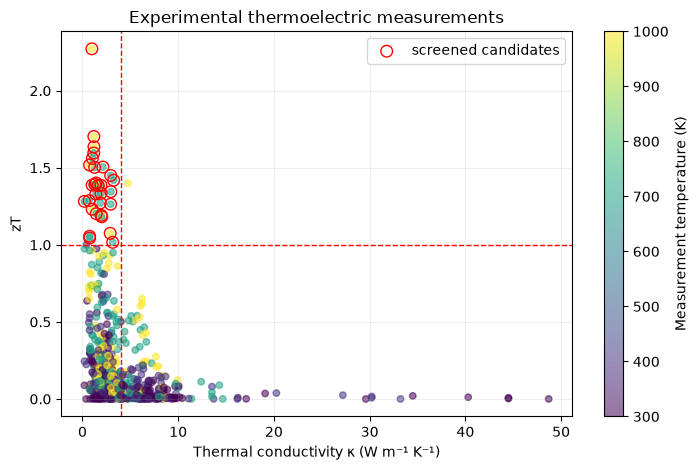

saved: /Users/kwongibaek/Desktop/workspace/26_AI4M/26년_1학기/Hands-on-session1_2026/outputs/03_advanced/ucsb_experimental_screening_candidates.csv


In [29]:
## 실험 후보 표를 CSV로 저장하고, 전체 측정 자료 위에 후보와 선별 기준을 표시합니다.
candidate_path = OUTPUT_DIR / "ucsb_experimental_screening_candidates.csv"
## index=False로 pandas 행 번호를 제외하고 저장합니다. candidate_path는 결과 파일의 전체 경로입니다.
candidates.to_csv(candidate_path, index=False)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
## 가로축은 κ, 세로축은 zT이며 c에 전달한 온도가 점의 색을 정합니다.
scatter = ax.scatter(
    usable["kappa [W/mK]"], usable["zT"],
    c=usable["T [K]"], cmap="viridis", s=22, alpha=0.55,
)
## 후보 행은 속이 빈 빨간 원으로 덧그립니다. 두 점선은 zT 하한과 κ 상한을 표시합니다.
ax.scatter(candidates["kappa [W/mK]"], candidates["zT"],
           facecolors="none", edgecolors="red", s=70, label="screened candidates")
ax.axhline(ZT_MIN, color="red", linestyle="--", linewidth=1)
ax.axvline(KAPPA_MAX, color="red", linestyle="--", linewidth=1)
ax.set(xlabel="Thermal conductivity κ (W m⁻¹ K⁻¹)", ylabel="zT",
       title="Experimental thermoelectric measurements")
## 색상 막대로 측정 온도를 읽을 수 있게 하고, 완성한 그림을 파일과 노트북 화면에 함께 출력합니다.
fig.colorbar(scatter, ax=ax, label="Measurement temperature (K)")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ucsb_experimental_screening.png", dpi=180)
plt.show()
print("saved:", candidate_path)

**짧은 과제 3:** `ZT_MIN`, `TEMP_RANGE_K`, `KAPPA_MAX` 가운데 하나만 바꾸어 보세요. 후보 측정 행 수와
고유 조성 수를 함께 보고하고, 두 수가 다른 이유를 설명해 주세요.

온도 하한을 낮추었는데도 후보 수가 같다면, 새로 포함된 온도 구간의 측정값이 나머지 조건을 만족하는지 확인하고 이유를 설명해 주세요.

*풀이 방향은 수업 후 자료에서 확인할 수 있습니다.*

### MP 계산 물성을 이용한 추가 스크리닝(선택)

다음 셀은 Bi와 Te를 포함한 물질에서 계산 band gap, hull 거리, 밀도, 탄성 자료를 함께 조회합니다.
실험 $zT$와 계산 band gap은 측정 방법과 의미가 다르므로 한 표에 합치지 않습니다. 대신 별도 표에
`data_origin='MP computed summary'`를 기록합니다.

예시 조건은 `0.05 ≤ band gap ≤ 1.0 eV`, `energy_above_hull ≤ 0.05 eV/atom`,
`10 ≤ K_VRH ≤ 150 GPa`입니다. `bulk_modulus['vrh']`가 없는 행은 제외합니다. 조건을 만족하는 자료가 하나도 없으면
빈 표에서 오류를 내지 않고 후보 수 0을 출력합니다.

In [30]:
## 라이브 조회가 켜져 있으면 조성·밴드갭·안정성·체적 탄성률 조건으로 계산 물성 후보를 검색합니다.
live_mp_screen = pd.DataFrame()
## 실행 스위치와 API 키가 모두 준비된 경우에만 조회합니다. 체적 탄성률 범위의 단위는 GPa입니다.
if RUN_LIVE_MP and MP_API_KEY:
    BULK_MODULUS_RANGE_GPA = (10.0, 150.0)
    ## with로 API 연결을 관리합니다. search의 조건들은 서버에서 후보를 좁히고, fields는 돌려받을 항목을
    ## 지정합니다.
    with MPRester(MP_API_KEY) as mpr:
        docs = mpr.materials.summary.search(
            ## Bi와 Te를 포함하는 2–4원소계를 요청합니다. 밴드갭은 eV, hull 위 에너지는 eV/atom 범위로
            ## 지정합니다.
            elements=["Bi", "Te"],
            num_elements=(2, 4),
            band_gap=(0.05, 1.0),
            energy_above_hull=(0.0, 0.05),
            k_vrh=BULK_MODULUS_RANGE_GPA,
            has_props=["elasticity"],
            fields=["material_id", "formula_pretty", "band_gap",
                    "energy_above_hull", "density", "bulk_modulus"],
        )
    rows = []
    ## 조회 문서를 하나씩 읽어 딕셔너리으로 바꿉니다. bulk_modulus가 없으면 빈 딕셔너리을 써서 vrh 값을
    ## 조회합니다.
    for doc in docs:
        bulk = doc.bulk_modulus or {}
        rows.append({
            "material_id": str(doc.material_id),
            "formula": doc.formula_pretty,
            "band_gap_eV": doc.band_gap,
            "e_above_hull_eV_atom": doc.energy_above_hull,
            "density_g_cm3": doc.density,
            "bulk_modulus_vrh_GPa": bulk.get("vrh"),
            "data_origin": "MP computed summary",
        })
    live_columns = ["material_id", "formula", "band_gap_eV",
                    "e_above_hull_eV_atom", "density_g_cm3",
                    "bulk_modulus_vrh_GPa", "data_origin"]
    ## 열 순서를 정해 표를 만들고, 선별에 필요한 밴드갭·안정성·탄성률 값이 누락된 행을 제외합니다.
    live_mp_screen = pd.DataFrame(rows, columns=live_columns).dropna(
        subset=["band_gap_eV", "e_above_hull_eV_atom", "bulk_modulus_vrh_GPa"]
    )
    ## 반환된 체적 탄성률이 설정 범위 안에 있는지 표에서도 확인합니다. between은 하한과 상한을 포함합니다.
    live_mp_screen = live_mp_screen[
        live_mp_screen["bulk_modulus_vrh_GPa"].between(*BULK_MODULUS_RANGE_GPA)
    ]
    ## hull 위 에너지가 작은 순서로 정렬하고, 값이 같으면 체적 탄성률이 큰 행을 먼저 배치합니다.
    live_mp_screen = live_mp_screen.sort_values(
        ["e_above_hull_eV_atom", "bulk_modulus_vrh_GPa"],
        ascending=[True, False],
    )
    print("live MP candidates:", len(live_mp_screen))
    display(live_mp_screen.head(12))
    ## 후보가 있을 때 결과 표를 CSV로 저장합니다. 라이브 조회가 꺼져 있으면 아래 else의 안내만 출력합니다.
    if not live_mp_screen.empty:
        live_mp_screen.to_csv(OUTPUT_DIR / "mp_computed_screening_live.csv", index=False)
else:
    print("건너뜀: 라이브 계산 물성 스크리닝은 RUN_LIVE_MP=True일 때만 실행됩니다.")

건너뜀: 라이브 계산 물성 스크리닝은 RUN_LIVE_MP=True일 때만 실행됩니다.


## 선택 심화 과제

아래 문제는 성적에 반영하지 않습니다. 관심 있는 항목을 골라 결과와 해석을 간단히 정리해 보세요.

1. **온도 민감도:** Mn–O 곡선에서 300–900 K와 1200–1800 K의 평균 기울기를 각각 구하고 차이를 설명해 주세요.
2. **자료 범위 확인:** 라이브 실행 후 `GGA_GGA+U`와 `R2SCAN`에서 목표 조성별 계산 자료 수와 `material_id` 교집합을 표로 만드세요.
   r2SCAN 자료가 없을 때는 에너지를 0으로 바꾸지 말고 결측값으로 남기세요.
3. **Pareto 후보:** UCSB 후보에서 $zT$는 클수록 좋고 $\kappa$는 작을수록 좋다고 할 때, 다른 행에 지배되지 않는 측정값을 찾아보세요.
4. **낮은 온도까지 포함하기:** `TEMP_RANGE_K`의 하한을 500 K에서 400 K로 낮추고 후보를 다시 고르세요. 후보가 그대로여도
   계산 오류라고 단정하지 말고, 새로 포함된 $400 \leq T < 500$ K 측정값이 다른 조건을 만족하는지 확인해 이유를 설명해 주세요.

*풀이 방향은 수업 후 자료에서 확인할 수 있습니다.*

## 출처와 재현에 필요한 정보

- MP API 질의와 계산 출처 확인: [Querying Data](https://docs.materialsproject.org/downloading-data/using-the-api/querying-data)
- GGA/GGA+U 및 r2SCAN 혼합 hull 구성: [Phase Diagrams](https://docs.materialsproject.org/methodology/materials-methodology/thermodynamic-stability/phase-diagrams-pds)
- r2SCAN 자료의 데이터베이스 변경 이력: [Database Versions](https://docs.materialsproject.org/changes/database-versions)
- 이 실습에서 사용한 커밋의 Gibbs 구현: [pymatgen source](https://github.com/materialsproject/pymatgen/blob/0428f232a569ffe6b16fa030d38ea35a56d70fd6/src/pymatgen/analysis/compatibility/computed_entries.py)
- Li–Fe–P–O 캐시: [pinned public fixture](https://raw.githubusercontent.com/materialsproject/pymatgen/0428f232a569ffe6b16fa030d38ea35a56d70fd6/test-files/entries/Li-Fe-P-O_entries.json)
- Mn–O 캐시와 pymatgen 검사 코드: [fixture](https://raw.githubusercontent.com/materialsproject/pymatgen/0428f232a569ffe6b16fa030d38ea35a56d70fd6/test-files/entries/Mn-O_entries.json), [test](https://github.com/materialsproject/pymatgen/blob/0428f232a569ffe6b16fa030d38ea35a56d70fd6/tests/analysis/compatibility/test_computed_entries.py#L467)
- Bartel et al., *Nature Communications* 9, 4168 (2018): [DOI](https://doi.org/10.1038/s41467-018-06682-4)
- UCSB 열전 데이터의 원 논문: Gaultois et al., *Chem. Mater.* 25, 2911 (2013), [DOI](https://doi.org/10.1021/cm400893e)

노트북을 제출하거나 다른 환경에서 다시 실행할 때는 `versions`, `sources.json`, 사용한 선별 기준,
라이브 조회 여부와 MP 데이터베이스 버전을 함께 기록해 주세요.